In [13]:
import numpy as np
import matplotlib.pyplot as plt

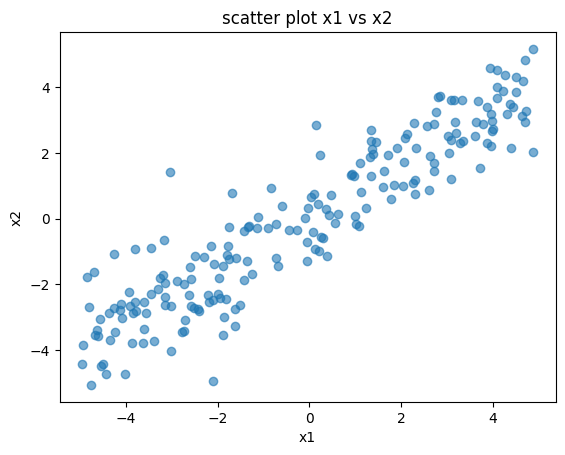

In [14]:
np.random.seed(42) # rastgeleliği sabitliyor kod her çalıştığında aynı sonucu elde ediyoruz 

n = 200

x1 = np.random.uniform(-5, 5, n) # -5 ile 5 arasından düzgün dağılıma sahip değerler üretiyoruz 

noise = np.random.normal(0, 1, n) 
x2 = 0.8*x1 +noise                   # x2 yi x1 i kullanarak üretiyoruz korelasyon olması için ama kolineer olmamalı  x2 bu yüzden noise(gürültü) ekliyoruz

X = np.column_stack((x1, x2))  # x1 ve x2 yi matris haline getiriyoruz 

plt.scatter(x1, x2, alpha=0.6) # scaterplot// x1 ve x2 arasındaki ilişki 
plt.title('scatter plot x1 vs x2')
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

In [ ]:
# Gram-Schmidt Ortonormalizasyon

v1 = X[:, 0] # x1 vektörü

v2 = X[:, 1] # x2 vektörü 

u1 = v1.copy()

proj_v2_on_u1 = (np.dot(v2, u1) / np.dot(u1, u1)) * u1 # v2 nin u1 projeksiyonu 

u2 = v2 - proj_v2_on_u1

e1 = u1 / np.linalg.norm(u1)
e2 = u2 / np.linalg.norm(u2)

print("e1 ve e2 ortonormal mı?")
print("e1 dot e2 =", np.dot(e1, e2))

e1 ve e2 ortonormal mı?
e1 dot e2 = 9.272096979096034e-16


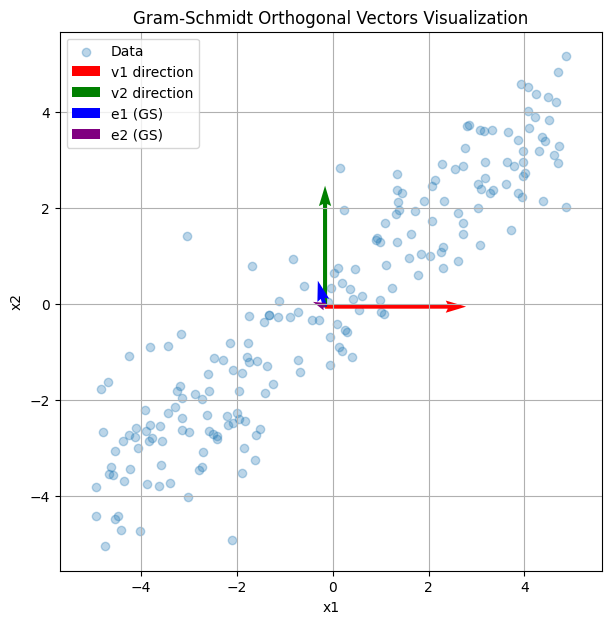

In [ ]:
plt.figure(figsize=(7, 7))

# scatter
plt.scatter(x1, x2, alpha=0.3, label="Data")

# merkezi referans noktası olarak ortalamaları alıyoruz
origin = [np.mean(x1), np.mean(x2)]

# orijinal yön v1 ve v2
plt.quiver(origin[0], origin[1], v1.std(), 0, color='red', angles='xy', scale_units='xy', scale=1, label='v1 direction')
plt.quiver(origin[0], origin[1], 0, v2.std(), color='green', angles='xy', scale_units='xy', scale=1, label='v2 direction')

# ortonormal yönler e1 ve e2
plt.quiver(origin[0], origin[1], e1[0]*5, e1[1]*5, color='blue', angles='xy', scale_units='xy', scale=1, label='e1 (GS)')
plt.quiver(origin[0], origin[1], e2[0]*5, e2[1]*5, color='purple', angles='xy', scale_units='xy', scale=1, label='e2 (GS)')

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Gram-Schmidt Orthogonal Vectors Visualization')
plt.legend()
plt.grid(True, )
plt.axis('equal')
plt.show()


In [ ]:
# 1) Veriyi ortalamadan arındırıyoruz
X_centered = X - np.mean(X, axis=0)

# 2) Kovaryans matrisini hesaplıyoruz
cov_matrix = np.cov(X_centered, rowvar=False)

print("Kovaryans matrisi:\n", cov_matrix)

# 3) Eigenvalue ve Eigenvector'lar
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("\nEigenvalues:", eigenvalues)
print("Eigenvectors:\n", eigenvectors)

Kovaryans matrisi:
 [[8.69609562 6.88898515]
 [6.88898515 6.39592387]]

Eigenvalues: [14.53033604  0.56168344]
Eigenvectors:
 [[ 0.76310769 -0.64627135]
 [ 0.64627135  0.76310769]]


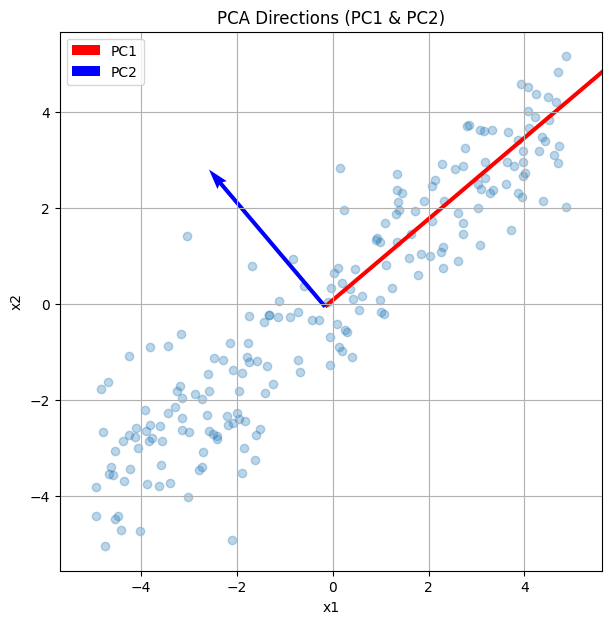

In [24]:
plt.figure(figsize=(7,7))
plt.scatter(x1, x2, alpha=0.3)

origin = np.mean(X, axis=0)

# PCA bileşenleri
pc1 = eigenvectors[:, 0] * np.sqrt(eigenvalues[0]) * 5
pc2 = eigenvectors[:, 1] * np.sqrt(eigenvalues[1]) * 5

plt.quiver(origin[0], origin[1], pc1[0], pc1[1],
           angles='xy', scale_units='xy', scale=1, color='red', label='PC1')

plt.quiver(origin[0], origin[1], pc2[0], pc2[1],
           angles='xy', scale_units='xy', scale=1, color='blue', label='PC2')

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("PCA Directions (PC1 & PC2)")
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()


In [26]:
XTX = np.dot(X_centered.T, X_centered)

print("X^T X matrisi:\n", XTX)

X^T X matrisi:
 [[1730.52302798 1370.90804426]
 [1370.90804426 1272.78885003]]


In [27]:
det_XTX = np.linalg.det(XTX)
print("det(X^T X) =", det_XTX)

det(X^T X) = 323201.54892060795


In [28]:
cond_XTX = np.linalg.cond(XTX)
print("Condition Number =", cond_XTX)

Condition Number = 25.869261811674754


In [29]:
true_w1 = 3
true_w2 = 2

y = true_w1 * x1 + true_w2 * x2 + np.random.normal(0, 2, n)

In [30]:
# X'e bias terimi (1'ler sütunu) ekleyelim
X_bias = np.column_stack((np.ones(n), X))

# Normal Equation: w = (X^T X)^(-1) X^T y
w_normal = np.linalg.inv(X_bias.T @ X_bias) @ (X_bias.T @ y)

w_normal

array([-0.09914878,  3.13700244,  1.86871507])

In [34]:
lambda_val = 1.0  # regularization strength

# I matrisi (bias hariç)
I = np.eye(X_bias.shape[1])
I[0, 0] = 0  # bias terimini regularize etmiyoruz

w_ridge = np.linalg.inv(X_bias.T @ X_bias + lambda_val * I) @ (X_bias.T @ y)

w_ridge

array([-0.09965428,  3.13260632,  1.87197933])

In [35]:
print("Normal Equation w:", w_normal)
print("Ridge Regression w:", w_ridge)

Normal Equation w: [-0.09914878  3.13700244  1.86871507]
Ridge Regression w: [-0.09965428  3.13260632  1.87197933]
